# buildingSMART Sample Models — Comparative Analysis

This notebook analyses all **14 IFC sample models** in [`../`](../) — the
[buildingSMART](https://www.buildingsmart.org/) example files used to test
schema conformance and viewer support — side by side, in one place.

The set splits into three groups:

| Category | Files | What they're for |
|---|---|---|
| **Building** | `Building-Architecture`, `Building-Hvac`, `Building-Landscaping`, `Building-Structural` | Discipline-specific slices of one building project |
| **Infrastructure** | `Infra-Bridge`, `Infra-Landscaping`, `Infra-Plumbing`, `Infra-Rail`, `Infra-Road` | IFC4X3 infrastructure showcase models (bridges, rail, road corridors) |
| **Geometry primitive** | `basin-tessellation`, `column-straight-rectangle-tessellation`, `tessellated-item`, `tessellation-with-individual-colors`, `wall-with-opening-and-window` | Minimal single/few-element files that exercise one geometry or relationship feature each |

## What's in here

1. **Inventory** — schema, entity counts, element-type composition, loaded into one comparison table.
2. **Graph gallery** — every model turned into a relationship graph (spatial containment + openings) and rendered **side by side** in a static grid, plus a nodes/edges comparison chart.
3. **Interactive graphs** — full interactive PyVis views, saved per model, linked from a table (kept out of the notebook body so 14 embedded graphs don't bloat it).

Run top to bottom; every cell is local-file based (no downloads) since the
samples already live one directory up.

In [1]:
# If running somewhere without the deps pre-installed, uncomment:
# !pip install -q ifcopenshell pandas numpy networkx pyvis matplotlib

import os
import glob
from collections import Counter

import ifcopenshell
import pandas as pd
import numpy as np
import networkx as nx
from networkx.readwrite import json_graph
from pyvis.network import Network
from IPython.display import HTML, display

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

In [2]:
# Shared categorical palette (fixed order — never reassign per-filter).
# Colorblind-validated: blue, orange, aqua, yellow, magenta, green, violet, red.
CATEGORICAL = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100",
               "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
SEQUENTIAL_BLUE = "#2a78d6"

SAMPLES_DIR = ".."
GRAPHS_DIR = "graphs"
os.makedirs(GRAPHS_DIR, exist_ok=True)

CATEGORY = {
    "Building-Architecture.ifc": "Building",
    "Building-Hvac.ifc": "Building",
    "Building-Landscaping.ifc": "Building",
    "Building-Structural.ifc": "Building",
    "Infra-Bridge.ifc": "Infrastructure",
    "Infra-Landscaping.ifc": "Infrastructure",
    "Infra-Plumbing.ifc": "Infrastructure",
    "Infra-Rail.ifc": "Infrastructure",
    "Infra-Road.ifc": "Infrastructure",
    "basin-tessellation.ifc": "Geometry primitive",
    "column-straight-rectangle-tessellation.ifc": "Geometry primitive",
    "tessellated-item.ifc": "Geometry primitive",
    "tessellation-with-individual-colors.ifc": "Geometry primitive",
    "wall-with-opening-and-window.ifc": "Geometry primitive",
}
CATEGORY_COLOR = {
    "Building": CATEGORICAL[0],
    "Infrastructure": CATEGORICAL[1],
    "Geometry primitive": CATEGORICAL[2],
}

ifc_files = sorted(f for f in os.listdir(SAMPLES_DIR) if f.lower().endswith(".ifc"))
print(f"{len(ifc_files)} IFC sample files found")
ifc_files

14 IFC sample files found


['Building-Architecture.ifc',
 'Building-Hvac.ifc',
 'Building-Landscaping.ifc',
 'Building-Structural.ifc',
 'Infra-Bridge.ifc',
 'Infra-Landscaping.ifc',
 'Infra-Plumbing.ifc',
 'Infra-Rail.ifc',
 'Infra-Road.ifc',
 'basin-tessellation.ifc',
 'column-straight-rectangle-tessellation.ifc',
 'tessellated-item.ifc',
 'tessellation-with-individual-colors.ifc',
 'wall-with-opening-and-window.ifc']

In [3]:
# Load every model once, keep them in memory keyed by filename
models = {}
for fn in ifc_files:
    models[fn] = ifcopenshell.open(os.path.join(SAMPLES_DIR, fn))

for fn, m in models.items():
    print(f"{fn:45s} schema={m.schema}")

Building-Architecture.ifc                     schema=IFC4X3
Building-Hvac.ifc                             schema=IFC4X3
Building-Landscaping.ifc                      schema=IFC4X3
Building-Structural.ifc                       schema=IFC4X3
Infra-Bridge.ifc                              schema=IFC4X3
Infra-Landscaping.ifc                         schema=IFC4X3
Infra-Plumbing.ifc                            schema=IFC4X3
Infra-Rail.ifc                                schema=IFC4X3
Infra-Road.ifc                                schema=IFC4X3
basin-tessellation.ifc                        schema=IFC4
column-straight-rectangle-tessellation.ifc    schema=IFC4
tessellated-item.ifc                          schema=IFC4
tessellation-with-individual-colors.ifc       schema=IFC4
wall-with-opening-and-window.ifc              schema=IFC4


## 1 · Inventory comparison

One row per model: schema version, element counts, dominant element type,
and file size — the fastest way to see how differently sized and shaped
these 14 files are.

In [4]:
rows = []
type_counts_by_model = {}

for fn, m in models.items():
    elems = m.by_type("IfcElement")
    type_counts = Counter(e.is_a() for e in elems)
    type_counts_by_model[fn] = type_counts

    rows.append({
        "file": fn,
        "category": CATEGORY.get(fn, "Other"),
        "schema": m.schema,
        "n_root_entities": len(m.by_type("IfcRoot")),
        "n_elements": len(elems),
        "n_element_types": len(type_counts),
        "top_element_type": type_counts.most_common(1)[0][0] if type_counts else None,
        "n_storeys": len(m.by_type("IfcBuildingStorey")),
        "n_sites": len(m.by_type("IfcSite")),
        "size_kb": round(os.path.getsize(os.path.join(SAMPLES_DIR, fn)) / 1024, 1),
    })

df_inventory = pd.DataFrame(rows).sort_values(["category", "file"]).reset_index(drop=True)
df_inventory

,file,category,schema,n_root_entities,n_elements,n_element_types,top_element_type,n_storeys,n_sites,size_kb
0,Building-Architecture.ifc,Building,IFC4X3,93,15,7,IfcBuildingElementProxy,1,2,215.6
1,Building-Hvac.ifc,Building,IFC4X3,39,6,4,IfcBuildingElementProxy,1,2,175.2
2,Building-Landscaping.ifc,Building,IFC4X3,34,7,2,IfcGeographicElement,0,2,1433.2
3,Building-Structural.ifc,Building,IFC4X3,82,18,7,IfcBeam,1,2,285.4
4,basin-tessellation.ifc,Geometry primitive,IFC4,8,1,1,IfcSanitaryTerminal,0,0,11.8
5,column-straight-rectangle-tessellation.ifc,Geometry primitive,IFC4,5,1,1,IfcColumn,0,1,4.5
6,tessellated-item.ifc,Geometry primitive,IFC4,5,1,1,IfcBuildingElementProxy,0,0,5.1
7,tessellation-with-individual-colors.ifc,Geometry primitive,IFC4,5,1,1,IfcBuildingElementProxy,0,0,2.5
8,wall-with-opening-and-window.ifc,Geometry primitive,IFC4,24,3,3,IfcWall,1,1,12.2
9,Infra-Bridge.ifc,Infrastructure,IFC4X3,175,50,11,IfcBeam,0,6,1839.1


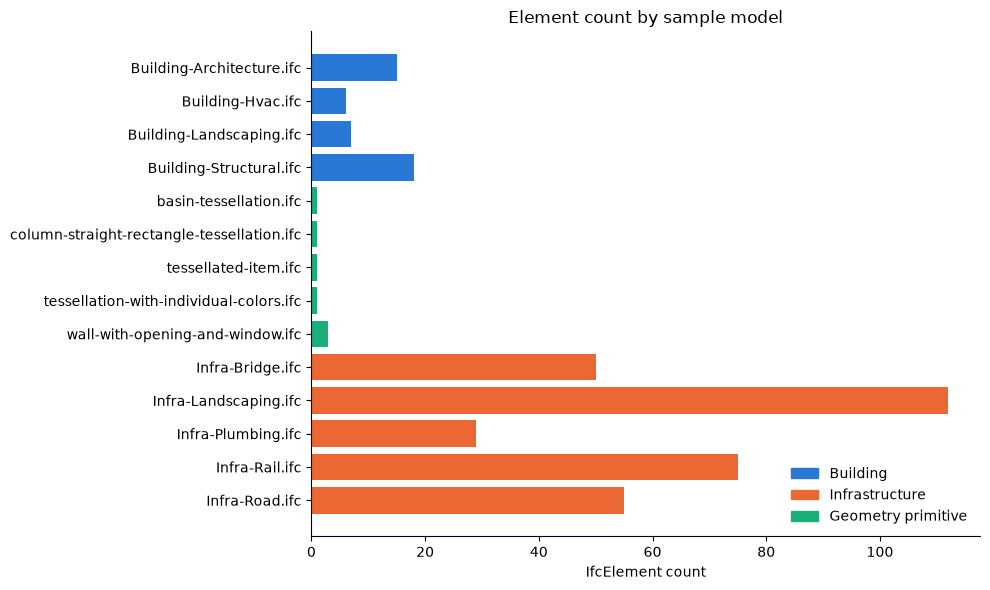

In [5]:
# Element count per model, colored by category
fig, ax = plt.subplots(figsize=(10, 6))
colors = [CATEGORY_COLOR[c] for c in df_inventory["category"]]
bars = ax.barh(df_inventory["file"], df_inventory["n_elements"], color=colors)
ax.set_xlabel("IfcElement count")
ax.set_title("Element count by sample model")
ax.invert_yaxis()
ax.spines[["top", "right"]].set_visible(False)

legend_handles = [mpatches.Patch(color=c, label=g) for g, c in CATEGORY_COLOR.items()]
ax.legend(handles=legend_handles, loc="lower right", frameon=False)
plt.tight_layout()
plt.show()

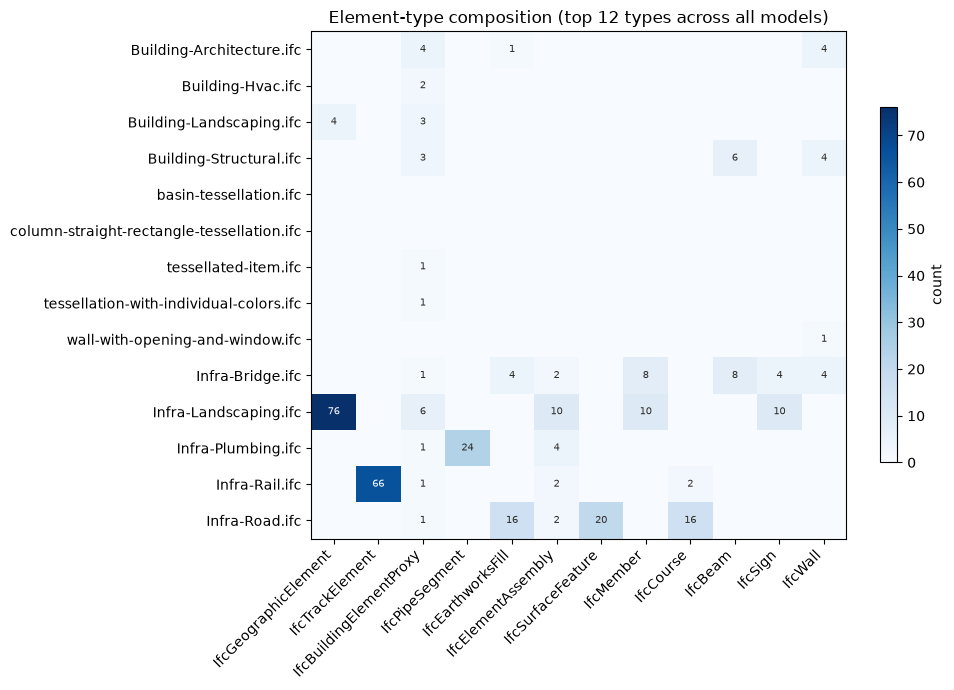

In [6]:
# Element-type composition heatmap — top 12 element types across all models
all_types = Counter()
for tc in type_counts_by_model.values():
    all_types.update(tc)
top_types = [t for t, _ in all_types.most_common(12)]

comp = pd.DataFrame(
    {fn: {t: type_counts_by_model[fn].get(t, 0) for t in top_types} for fn in models}
).T.loc[df_inventory["file"]]

fig, ax = plt.subplots(figsize=(10, 7))
im = ax.imshow(comp.values, aspect="auto", cmap="Blues")
ax.set_xticks(range(len(top_types)))
ax.set_xticklabels(top_types, rotation=45, ha="right")
ax.set_yticks(range(len(comp.index)))
ax.set_yticklabels(comp.index)
ax.set_title("Element-type composition (top 12 types across all models)")
for i in range(comp.shape[0]):
    for j in range(comp.shape[1]):
        v = comp.values[i, j]
        if v:
            ax.text(j, i, str(v), ha="center", va="center",
                    fontsize=7, color="white" if v > comp.values.max() / 2 else "#2b2b28")
fig.colorbar(im, ax=ax, shrink=0.7, label="count")
plt.tight_layout()
plt.show()

## 2 · Graph gallery — every model as a network, side by side

Each model is turned into a directed graph of:

- **spatial aggregation** — `IfcRelAggregates` between spatial nodes (`IfcProject → IfcSite → IfcBuilding → IfcBuildingStorey`, or whatever subset exists — several infrastructure samples skip straight from Site to elements)
- **spatial containment** — `IfcRelContainedInSpatialStructure`, whichever structure type relates the elements
- **openings** — `IfcRelVoidsElement` / `IfcRelFillsElement` (wall → opening → door/window)

The builder is written generically (no hard assumption of storeys existing)
because several of these samples — the infrastructure and geometry-primitive
files — have no `IfcBuildingStorey` at all.

In [7]:
SPATIAL_CLASSES = {
    "IfcProject", "IfcSite", "IfcBuilding", "IfcBuildingStorey", "IfcSpace",
    "IfcFacility", "IfcFacilityPart", "IfcBridge", "IfcRoad", "IfcRailway",
    "IfcMarineFacility", "IfcSpatialZone",
}

def node_label(e):
    return f"{e.is_a()}: {e.Name or e.GlobalId[:8]}"

def add_node(G, e, group=None):
    if e.GlobalId in G:
        return
    G.add_node(e.GlobalId, label=node_label(e), group=group or e.is_a())

def build_relations_graph(model):
    G = nx.DiGraph()

    for rel in model.by_type("IfcRelAggregates"):
        parent = rel.RelatingObject
        if parent.is_a() not in SPATIAL_CLASSES:
            continue
        add_node(G, parent, group=parent.is_a())
        for child in rel.RelatedObjects:
            if child.is_a() in SPATIAL_CLASSES:
                add_node(G, child, group=child.is_a())
                G.add_edge(parent.GlobalId, child.GlobalId, relation="aggregates")

    for rel in model.by_type("IfcRelContainedInSpatialStructure"):
        structure = rel.RelatingStructure
        add_node(G, structure, group=structure.is_a())
        for e in rel.RelatedElements:
            add_node(G, e, group=e.is_a())
            G.add_edge(structure.GlobalId, e.GlobalId, relation="contains")

    for rel in model.by_type("IfcRelVoidsElement"):
        wall, opening = rel.RelatingBuildingElement, rel.RelatedOpeningElement
        add_node(G, wall)
        add_node(G, opening, group="IfcOpeningElement")
        G.add_edge(wall.GlobalId, opening.GlobalId, relation="voids")

    for rel in model.by_type("IfcRelFillsElement"):
        opening, element = rel.RelatingOpeningElement, rel.RelatedBuildingElement
        add_node(G, opening, group="IfcOpeningElement")
        add_node(G, element)
        G.add_edge(opening.GlobalId, element.GlobalId, relation="fills")

    return G


graphs = {fn: build_relations_graph(m) for fn, m in models.items()}

df_graph_sizes = pd.DataFrame([
    {"file": fn, "nodes": G.number_of_nodes(), "edges": G.number_of_edges(),
     "weakly_connected_components": nx.number_weakly_connected_components(G)}
    for fn, G in graphs.items()
]).sort_values("file").reset_index(drop=True)
df_graph_sizes

,file,nodes,edges,weakly_connected_components
0,Building-Architecture.ifc,21,20,1
1,Building-Hvac.ifc,11,10,1
2,Building-Landscaping.ifc,10,9,1
3,Building-Structural.ifc,15,14,1
4,Infra-Bridge.ifc,75,59,16
5,Infra-Landscaping.ifc,111,110,1
6,Infra-Plumbing.ifc,39,38,1
7,Infra-Rail.ifc,86,83,3
8,Infra-Road.ifc,55,46,9
9,basin-tessellation.ifc,3,2,1


In [8]:
# Layered layout by BFS depth from the graph's root(s) — no Graphviz needed,
# renders as a plain static image so all 14 fit in one grid.
def layered_layout(G):
    roots = [n for n, d in G.in_degree() if d == 0]
    depth = {}
    frontier = roots
    d = 0
    while frontier:
        for n in frontier:
            depth.setdefault(n, d)
        nxt = []
        for n in frontier:
            for succ in G.successors(n):
                if succ not in depth:
                    nxt.append(succ)
        frontier = nxt
        d += 1

    by_depth = {}
    for n, dd in depth.items():
        by_depth.setdefault(dd, []).append(n)

    pos = {}
    for dd, nodes in by_depth.items():
        for i, n in enumerate(nodes):
            pos[n] = (i - len(nodes) / 2, -dd)
    return pos


def group_colors_for(G):
    groups = sorted({d.get("group", "?") for _, d in G.nodes(data=True)})
    palette = (CATEGORICAL * (len(groups) // len(CATEGORICAL) + 1))
    return {g: palette[i] for i, g in enumerate(groups)}

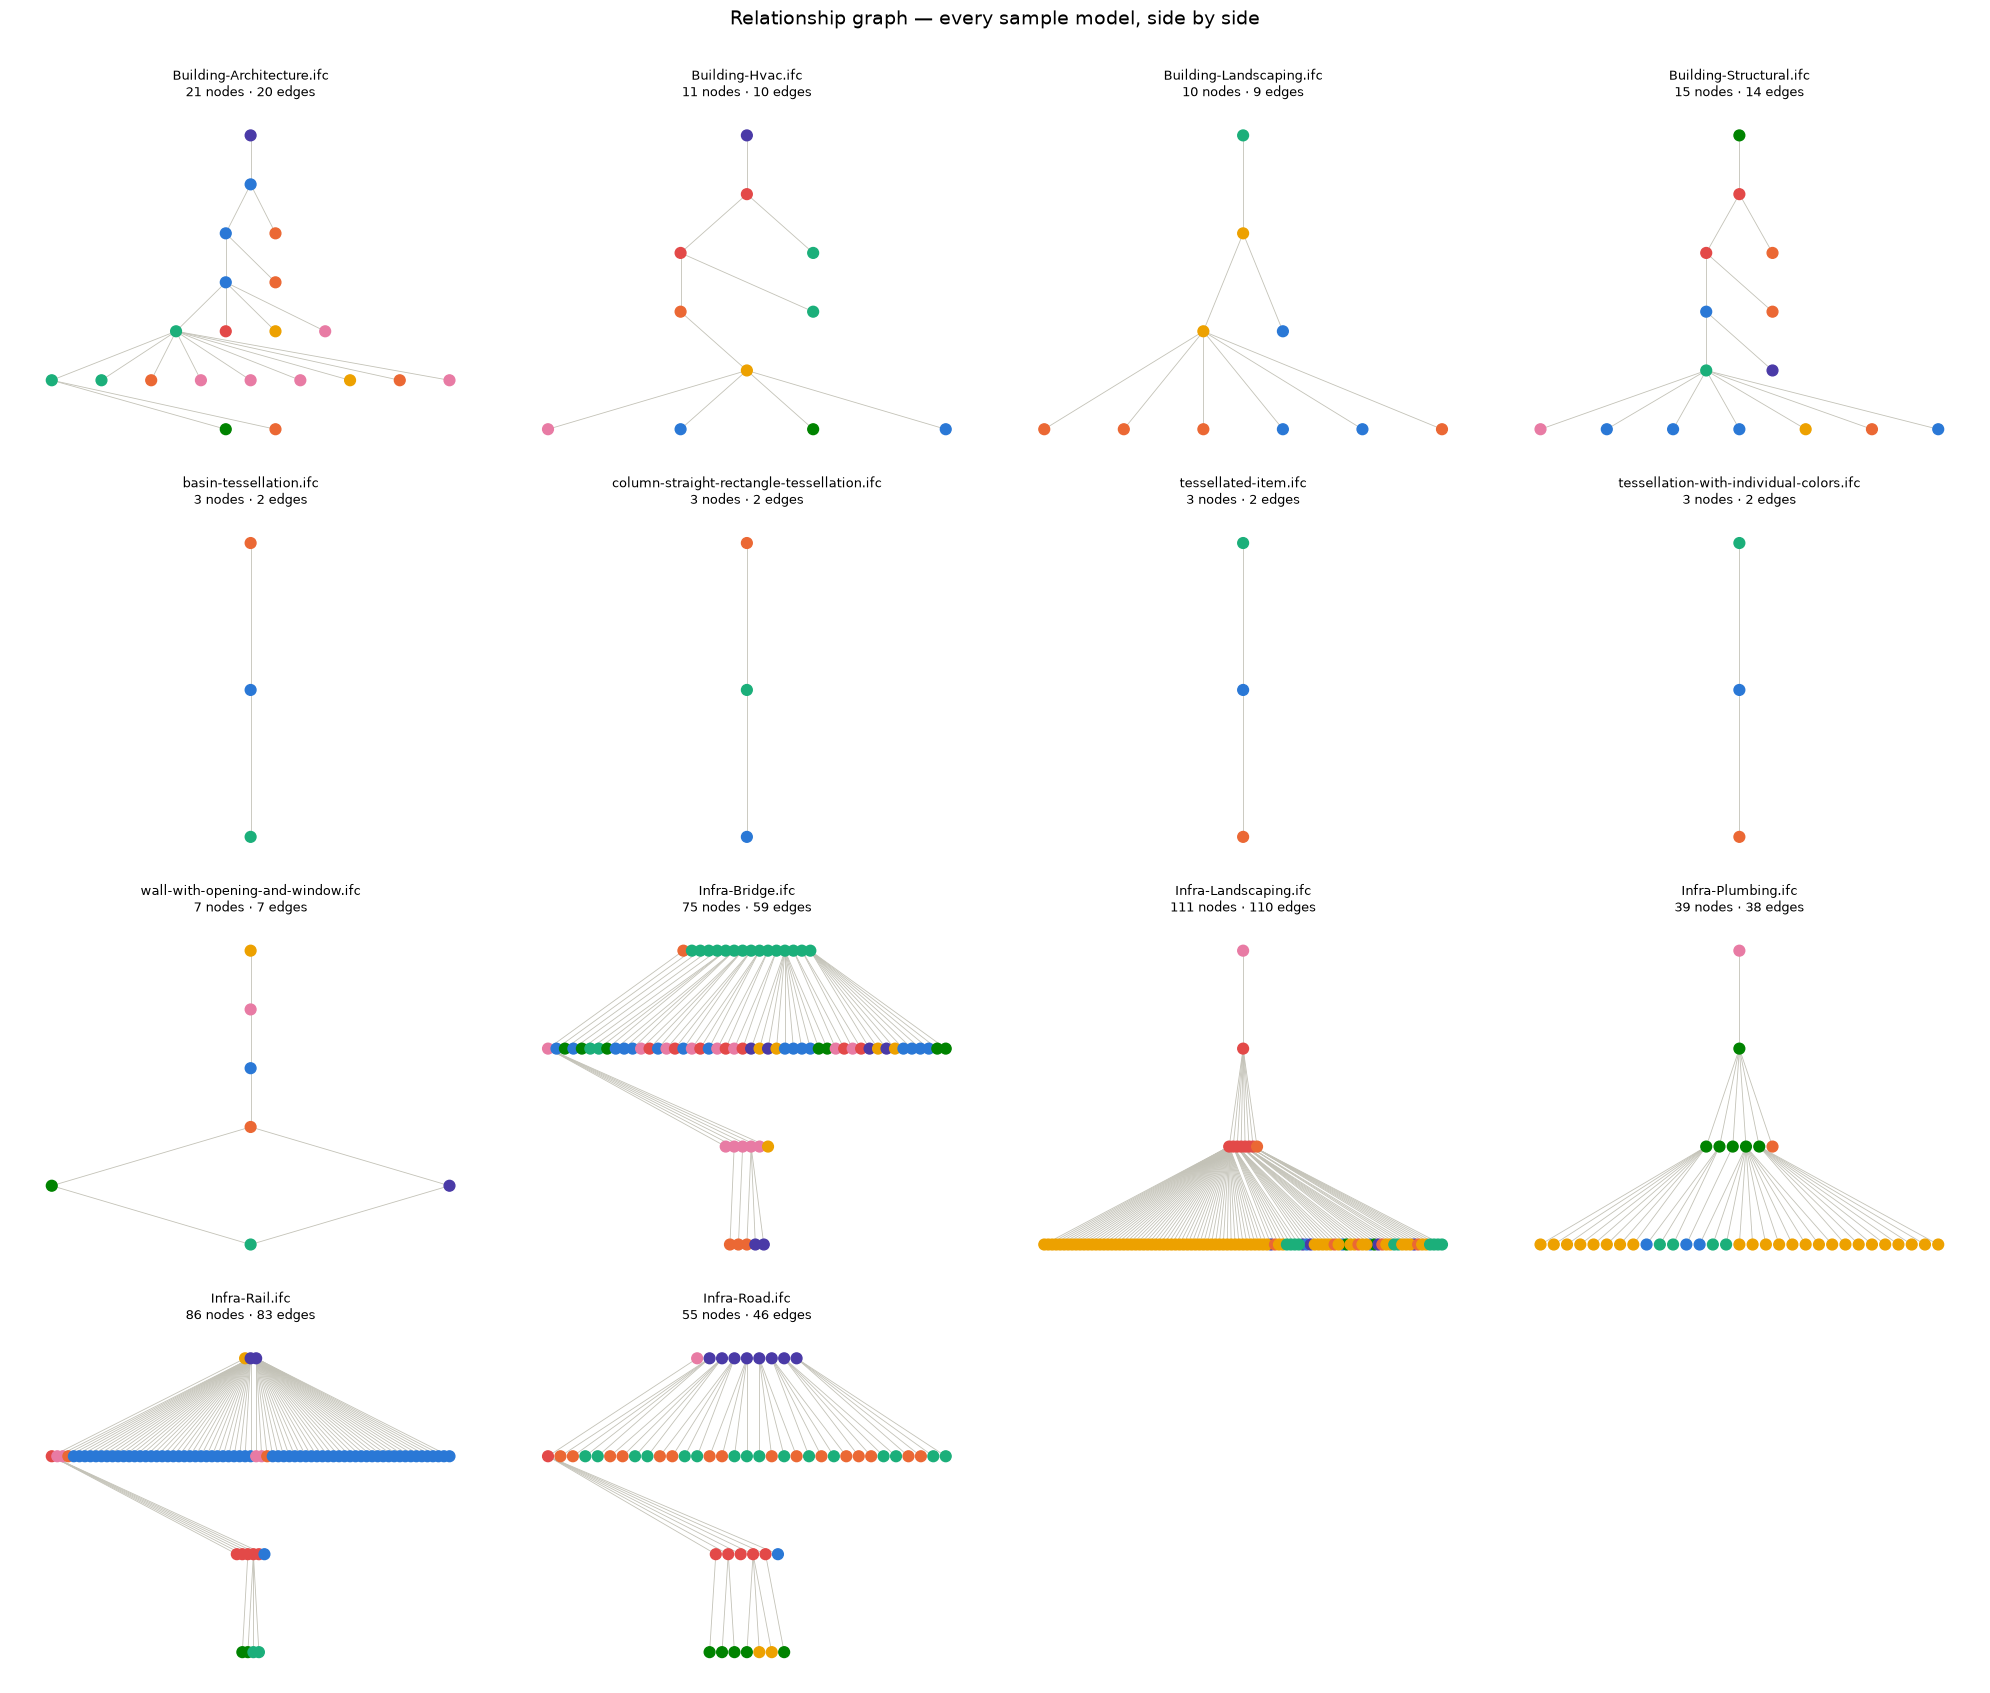

In [9]:
# --- Side-by-side grid: every model's relations graph, one panel each ---
files_sorted = df_inventory["file"].tolist()
n = len(files_sorted)
ncols = 4
nrows = -(-n // ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4.2 * nrows))
axes = axes.flatten()

for ax, fn in zip(axes, files_sorted):
    G = graphs[fn]
    if G.number_of_nodes() == 0:
        ax.set_title(f"{fn}\n(no graph)", fontsize=9)
        ax.axis("off")
        continue

    pos = layered_layout(G)
    gcolors = group_colors_for(G)
    node_colors = [gcolors[G.nodes[nd].get("group", "?")] for nd in G.nodes]

    nx.draw(
        G, pos, ax=ax, node_color=node_colors, node_size=60,
        edge_color="#c3c2b7", width=0.6, arrows=False, with_labels=False,
    )
    ax.set_title(f"{fn}\n{G.number_of_nodes()} nodes · {G.number_of_edges()} edges", fontsize=9)
    ax.axis("off")

for ax in axes[n:]:
    ax.axis("off")

fig.suptitle("Relationship graph — every sample model, side by side", fontsize=14, y=1.005)
plt.tight_layout()
plt.show()

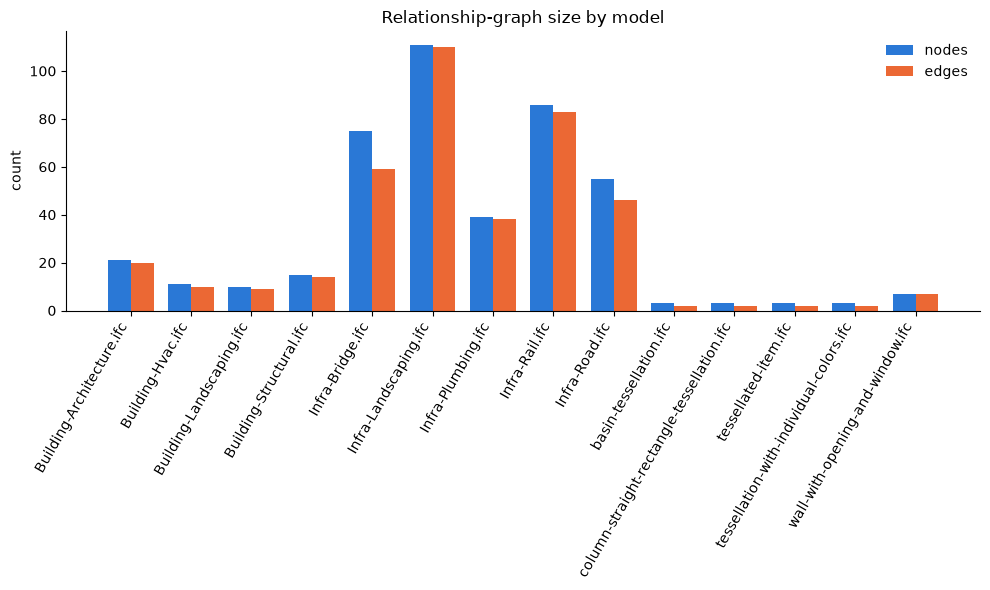

In [10]:
# --- Graph size comparison: nodes vs edges per model ---
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(df_graph_sizes))
width = 0.38
ax.bar(x - width / 2, df_graph_sizes["nodes"], width, label="nodes", color=CATEGORICAL[0])
ax.bar(x + width / 2, df_graph_sizes["edges"], width, label="edges", color=CATEGORICAL[1])
ax.set_xticks(x)
ax.set_xticklabels(df_graph_sizes["file"], rotation=60, ha="right")
ax.set_ylabel("count")
ax.set_title("Relationship-graph size by model")
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

## 3 · Interactive graphs (per model)

A full interactive PyVis view for every model, written to
[`graphs/`](./graphs/) as a standalone HTML file rather than embedded 14
times in this notebook. Click through from the table below.

In [11]:
interactive_paths = {}

for fn, G in graphs.items():
    if G.number_of_nodes() == 0:
        continue
    net = Network(height="700px", width="100%", directed=True, notebook=True, cdn_resources="in_line")
    net.from_nx(G)
    net.show_buttons(filter_=["physics"])

    out_name = os.path.splitext(fn)[0] + ".html"
    out_path = os.path.join(GRAPHS_DIR, out_name)
    html = net.generate_html(out_path, notebook=True)
    # Written explicitly as UTF-8 — several samples carry non-ASCII names,
    # and net.show()/generate_html's own write uses the platform default
    # encoding, which raises UnicodeEncodeError on Windows (cp1252).
    with open(out_path, "w", encoding="utf-8") as f:
        f.write(html)
    interactive_paths[fn] = out_path

df_links = pd.DataFrame({
    "file": list(interactive_paths.keys()),
    "interactive_graph": [f"[{os.path.basename(p)}]({p.replace(os.sep, '/')})" for p in interactive_paths.values()],
})
display(HTML(df_links.to_html(escape=False, index=False)))

file,interactive_graph
Building-Architecture.ifc,[Building-Architecture.html](graphs/Building-Architecture.html)
Building-Hvac.ifc,[Building-Hvac.html](graphs/Building-Hvac.html)
Building-Landscaping.ifc,[Building-Landscaping.html](graphs/Building-Landscaping.html)
Building-Structural.ifc,[Building-Structural.html](graphs/Building-Structural.html)
Infra-Bridge.ifc,[Infra-Bridge.html](graphs/Infra-Bridge.html)
Infra-Landscaping.ifc,[Infra-Landscaping.html](graphs/Infra-Landscaping.html)
Infra-Plumbing.ifc,[Infra-Plumbing.html](graphs/Infra-Plumbing.html)
Infra-Rail.ifc,[Infra-Rail.html](graphs/Infra-Rail.html)
Infra-Road.ifc,[Infra-Road.html](graphs/Infra-Road.html)
basin-tessellation.ifc,[basin-tessellation.html](graphs/basin-tessellation.html)


In [12]:
# Also export every graph as node-link JSON, for reuse outside this notebook
import json

for fn, G in graphs.items():
    out_path = os.path.join(GRAPHS_DIR, os.path.splitext(fn)[0] + ".json")
    with open(out_path, "w") as f:
        json.dump(json_graph.node_link_data(G), f)

print(f"Wrote {len(graphs)} HTML + {len(graphs)} JSON graphs to {os.path.abspath(GRAPHS_DIR)}")

Wrote 14 HTML + 14 JSON graphs to C:\Users\ReDI\Downloads\IfcOpenShell_Explorations\ifc_analysis_portfolio\building_smart-samples\notebooks\graphs


## Summary

- 14/14 sample models loaded, inventoried, and graphed without errors.
- The **Building** and **Infrastructure** samples form connected spatial
  graphs (site → discipline elements); the **geometry-primitive** samples
  are, as their names suggest, one or two elements with almost no
  relationship structure — that's expected, they exist to test a single
  geometry feature, not a spatial hierarchy.
- Full interactive graphs for every model are in [`graphs/`](./graphs/).